In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.datasets import make_moons
#make_blobs
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

In [ ]:
print("Dataset.shape:",X.shape)
print("Labels",np.unique(y))

Dataset.shape: (300, 2)
Labels [0 1]


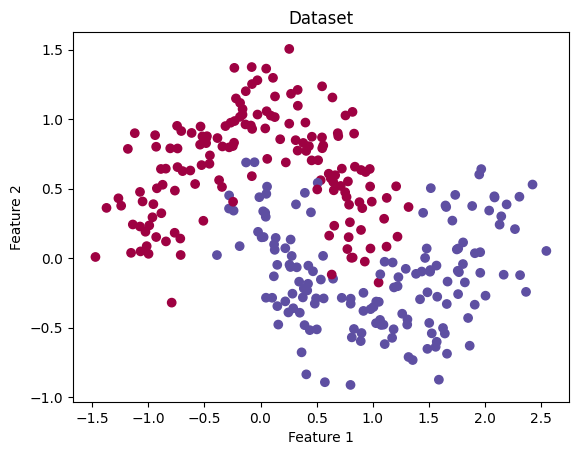

In [ ]:
#visualize the data
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.Spectral)
plt.title("Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
#Split the dataset into training and testing set
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
#train the SVM model
# kernel="linear" tells SVM to look for a straight-line boundary.
# C controls how strict the margin is. A large C tries hard to
# classify every training point correctly (smaller margin);
# a small C allows a wider margin even if a few points are
# misclassified. C=1.0 is a balanced default.
model=SVC(kernel="linear",C=1.0)
model.fit(X_train,y_train)

SVC(kernel='linear')

In [ ]:
#Identifying the support vectors
support_vectors = model.support_vectors_
print("\nNumber of support vectors:", len(support_vectors))
print("Support vector coordinates:\n", support_vectors)


Number of support vectors: 75
Support vector coordinates:
 [[ 0.76708377  0.4394785 ]
 [-1.01551816  0.08638537]
 [-0.71230646  0.02254423]
 [ 1.22126582  0.15432763]
 [ 1.10202882  0.28308355]
 [ 0.92964142 -0.02476026]
 [ 0.65717428  0.23306663]
 [ 0.625637    0.57469813]
 [-0.93095351  0.15176853]
 [ 0.90711637  0.35937885]
 [ 0.7249481   0.64351617]
 [ 0.66532508  0.59641558]
 [-0.76606932  0.18239308]
 [ 0.65306446  0.48779101]
 [ 0.99178492  0.40598726]
 [ 0.82148431  0.00416354]
 [ 0.50556338  0.49376984]
 [ 1.05268152 -0.17538912]
 [ 0.974076    0.64107754]
 [ 0.71499048  0.51894439]
 [ 0.97715216  0.51527727]
 [ 0.89587774  0.20262463]
 [ 0.63447432 -0.1179441 ]
 [ 0.80923886  0.00263434]
 [ 0.6080765   0.60696138]
 [-0.99905112  0.03098606]
 [-0.71582967  0.14092843]
 [ 0.7741308   0.06529453]
 [ 0.61197567  0.16169493]
 [ 0.78944629  0.38405983]
 [ 0.88176261  0.40255685]
 [ 1.12531214  0.43322439]
 [-0.2450336   0.40543788]
 [ 0.79692675  0.258008  ]
 [-0.84353885  0.12033

In [ ]:
#Visualize the hyperplane, margin, and support vectors



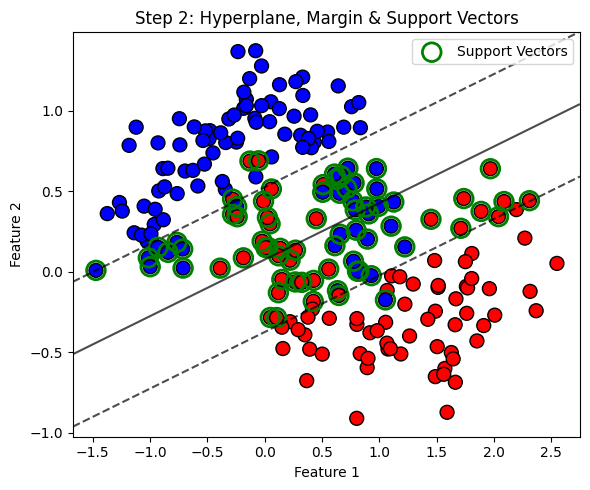

In [ ]:

# Build a grid of points covering the plot area so we can draw
# the decision boundary and margin lines using the model's
# "decision_function" (distance of each grid point from the hyperplane).
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr", s=100, edgecolors="k")
ax = plt.gca() #get current axis
xlim = ax.get_xlim()#get the minimum and maximum values of xaxis

ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 200)
yy = np.linspace(ylim[0], ylim[1], 200)
YY, XX = np.meshgrid(yy, xx)
grid = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(grid).reshape(XX.shape)
ax.contour(
    XX, YY, Z,
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.7,
    linestyles=["--", "-", "--"],
)
ax.scatter(
    support_vectors[:, 0], support_vectors[:, 1],
    s=180, facecolors="none", edgecolors="green", linewidths=2,
    label="Support Vectors"
)
plt.title("Step 2: Hyperplane, Margin & Support Vectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc="best")
plt.tight_layout()

In [ ]:
#make predictions on the test set
y_pred = model.predict(X_test)
print("\nActual labels:    ", y_test)
print("Predicted labels: ", y_pred)


Actual labels:     [1 1 1 1 1 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 0 1 0
 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1 1 0 0 1
 1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1]
Predicted labels:  [1 1 1 1 1 0 1 0 1 1 0 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0
 1 1 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 1 1 0 0 1 0 0 1 1 0 0 1
 1 0 0 0 0 0 0 1 0 0 1 1 1 1 1 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel accuracy on test data: {accuracy * 100:.2f}%")


Model accuracy on test data: 90.00%


In [ ]:
new_point=np.array([[X[:,0].mean(), X[:,-1].mean()]])
prediction=model.predict(new_point)
print("Prediction for new point:",prediction)
print(new_point)

Prediction for new point: [1]
[[0.93022073 5.53731255]]


In [ ]:
#extension of SVM Project
'''
Non-linear separation with kernels
try kernel="rbf" — a great visual for why the kernel trick exists.

Effect of C and gamma-
Iris flower classification- you may try this by building with SVM
Handwritten digit recognition- try using SVM
Titanic survival prediction

Face recognition with SVM +PCA
'''